In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import seaborn.objects as so
import jax.numpy as jnp
import arviz as az
import numpy as np
import xarray as xr

plt.style.use("cppp.notebook")
theme = {**sns.axes_style("ticks"), **rcParams}
so.Plot.config.theme.update(theme)

from cppp.load import load_multisensory_data
from cppp.utils import concat_log_likelihoods


/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Model results (10 June 2026)
## Before running this notebook

### 1. Model fitting
Run `fit_multisensory.py` for each participant and each model ("optimal", "no_integration", "equal_integration"), e.g.
```bash
python fit_multisensory.py --participant 135033060 --model optimal --model_class MultisensoryDelayModelPointMassDynamics
```

You can also specify a model class (e.g. `MultisensoryDelayModelPointMassDynamics` for the version with more realistic hand movement dynamics)

### 2. Model simulation
After fitting the models to the data from the baseline phase, we can simulate behaviour in the offset phase. For each participant run `simulate_multisensory.py`, e.g.
```bash
python simulate_multisensory.py --participant 135033060 --model_class MultisensoryDelayModelPointMassDynamics
```

## Load model fits

Load the model fit files for all three models for a single example participant

In [2]:
participant = 135033060
model_names =  ["optimal", "no_integration", "equal_integration"]

models = {
        model_name: az.from_netcdf(
            f"../results/multisensory-mcmc-{participant}_1_2_7453_1000_2500_4_{model_name}_MultisensoryDelayModelPointMassDynamics.nc"
        )
        for model_name in model_names
    }

# stack up log likelihoods for all 6 conditions into a single array for each model so that we can perform model comparison using all conditions together
models = {model_name: concat_log_likelihoods(model) for model_name, model in models.items()}

In [3]:
for model_name, model in models.items():
    print(model_name)
    print(az.summary(model))

optimal
                      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
action_cost          0.000  0.000   0.000    0.000      0.000    0.000   
action_variability   0.090  0.001   0.089    0.091      0.000    0.000   
sigma_prop           2.510  0.059   2.401    2.623      0.001    0.001   
sigma_vis[0]         5.204  0.292   4.682    5.762      0.003    0.003   
sigma_vis[1]        11.631  0.817  10.084   13.123      0.007    0.008   

                    ess_bulk  ess_tail  r_hat  
action_cost          12068.0    7838.0    1.0  
action_variability   13088.0    8055.0    1.0  
sigma_prop           12371.0    7719.0    1.0  
sigma_vis[0]         11308.0    7844.0    1.0  
sigma_vis[1]         12221.0    7867.0    1.0  
no_integration
                      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
action_cost          0.000  0.000   0.000    0.000      0.000    0.000   
action_variability   0.090  0.001   0.088    0.091      0.000    0.000   
sigma_prop           2

## Show parameter estimates

Parameter estimates for the following parameters
- visual noise (`sigma_vis`) in the low (1) and high (2) visual noise condition
- proprioceptive noise (`sigma_prop`)
- action variability (`action_variability`)
- action cost (`action_cost`)
compared across the three models

                      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
action_cost          0.000  0.000   0.000    0.000      0.000    0.000   
action_variability   0.090  0.001   0.089    0.091      0.000    0.000   
sigma_prop           2.510  0.059   2.401    2.623      0.001    0.001   
sigma_vis[0]         5.204  0.292   4.682    5.762      0.003    0.003   
sigma_vis[1]        11.631  0.817  10.084   13.123      0.007    0.008   

                    ess_bulk  ess_tail  r_hat  
action_cost          12068.0    7838.0    1.0  
action_variability   13088.0    8055.0    1.0  
sigma_prop           12371.0    7719.0    1.0  
sigma_vis[0]         11308.0    7844.0    1.0  
sigma_vis[1]         12221.0    7867.0    1.0  


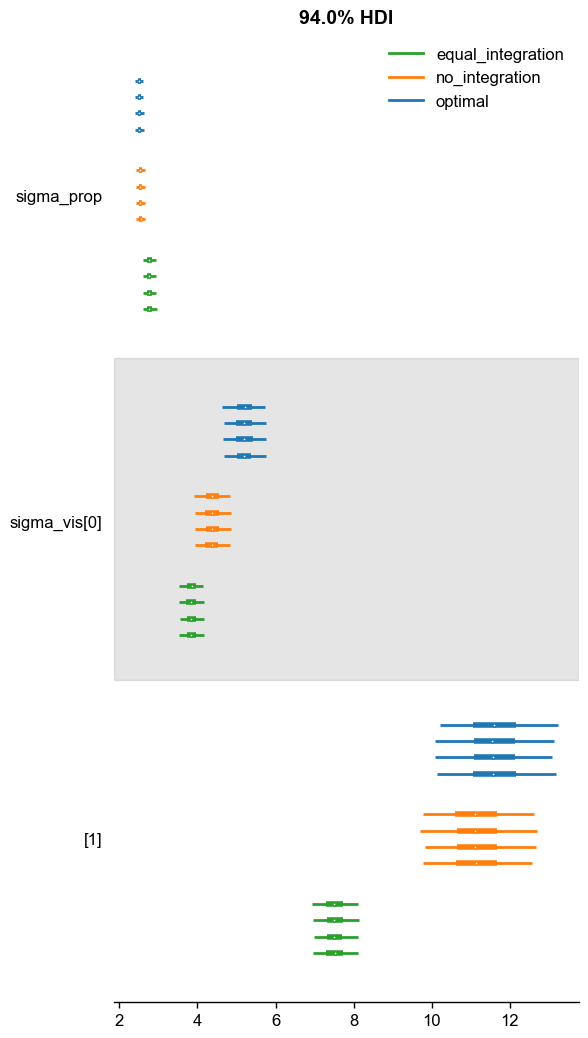

In [4]:
az.plot_forest(list(models.values()), model_names=list(models.keys()), var_names=["sigma_prop", "sigma_vis"])

print(az.summary(models["optimal"]))

## Model comparison

Use Pareto-smoothed importance sampling approximation to leave-one-out cross-validation (PSIS-LOO), implemented in `arviz` (https://python.arviz.org/en/v0.22.0/api/generated/arviz.loo.html) and described by Vehtari et al. (2017, https://link.springer.com/article/10.1007/S11222-016-9696-4).

I have now stacked the data from all conditions together, so that we can get a single model comparison score for each participant using all of their baseline phase data.

/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/scratch/ds2181/cpp-propri

                   rank      elpd_loo      p_loo   elpd_diff         weight  \
no_integration        0 -12553.403259  62.151672    0.000000   1.000000e+00   
optimal               1 -12586.441833  63.427689   33.038574   4.482595e-15   
equal_integration     2 -12796.729599  75.823380  243.326340  2.112095e-106   

                           se        dse  warning scale  
no_integration     280.894307   0.000000     True   log  
optimal            284.666416  10.421751     True   log  
equal_integration  287.813687  49.928883     True   log  


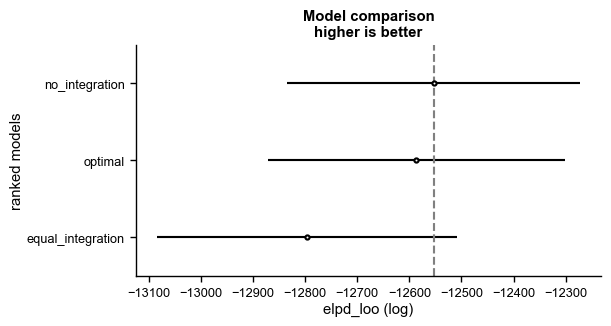

In [5]:
comp_df = az.compare(models, method="pseudo-BMA", ic="loo")
print(comp_df)
axes = az.plot_compare(comp_df=comp_df)


## Load data

Load data from all participants and compute tracking error

In [6]:
df = load_multisensory_data(base_path="../data")

df["tracking_error"] = df["lefty_pos"] - df["righty_pos"]

df["offset_sign"] = df.groupby("participant")["cursor_offset"].transform(lambda x: np.sign(x.mean()))

df["tracking_error"] *= df["offset_sign"]

df["time_within_trial"] = df.groupby(["participant", "trial_number"])["time"].transform(lambda x: x - x.min())

participants = df["participant"].unique()

participants_to_exclude = []
participants = [p for p in participants if p not in participants_to_exclude]

Multisensory DataFrame loaded from ../data/multisensory/df_all_phases_all_participants.csv with shape: (492343, 14)


## Load and plot simulated CCGs

We load the posterior-predictive checks for the cross-correlograms.

In [10]:
ccgs = pd.concat([pd.read_csv(f"../results/ppc/multisensory-simulations-ppc-{p}_1_2_7453_1000_2500_4_MultisensoryDelayModelPointMassDynamics.csv") for p in participants]).reset_index(drop=True)

ccgs["Condition"] = ccgs["condition"].map({"vis": "Vision", "prop": "Proprioception", "multi": "Multisensory"})
ccgs["Visual target"] = ccgs["vis_noise"].map({1: "Cursor", 2: "Cloud"})
ccgs["model"] = ccgs["model"].map({"data": "Data", "optimal": "Optimal integration", "no_integration": "No integration", "equal_integration": "Equal integration"})

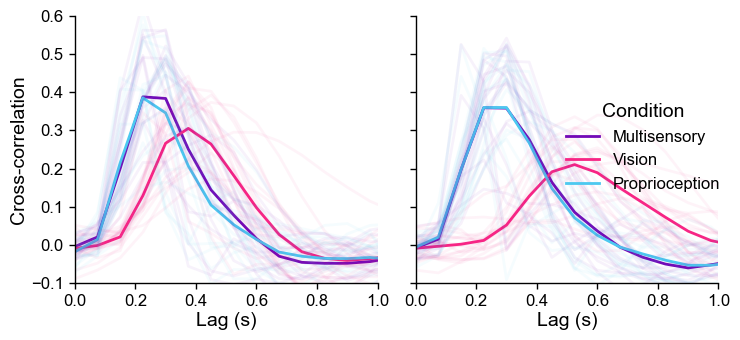

In [12]:
palette = {'Vision': "#F72585", 'Proprioception':  "#4CC9F0", 'Multisensory': "#7209B7"}
g = (so.Plot(ccgs[ccgs["model"] == "Data"], x="lag", y="correlation", color="Condition")
    .add(so.Line(), so.Agg())
    .add(so.Line(alpha=0.05), so.Agg(), group="participant")
    # .add(so.Band(), so.Est())
    .facet(col="vis_noise", 
    # row="model", order={"row": ["data", "optimal", "no_integration", "equal_integration"]}
           )
    .label(x="Lag (s)", y="Cross-correlation", title="")
    .limit(x=(-0.0, 1.0), y=(-0.1, 0.6))
    # .scale(color=so.Nominal({"vis": sns.color_palette("colorblind")[3], "prop": sns.color_palette("colorblind")[0], "multi": sns.color_palette("colorblind")[4]}))
    .scale(color=so.Nominal(palette))
    .layout(size=(7.5, 3.5))
)
g.show()

## CCG parameters (peak)

In [13]:
ccg_params = ccgs.groupby(["participant", "model", "Condition", "Visual target"]).apply(
    lambda g: pd.Series({
        'peak': g['correlation'].max(),
        'lag': g.loc[g['correlation'].idxmax(), 'lag']
    }),
    include_groups=False
).reset_index()

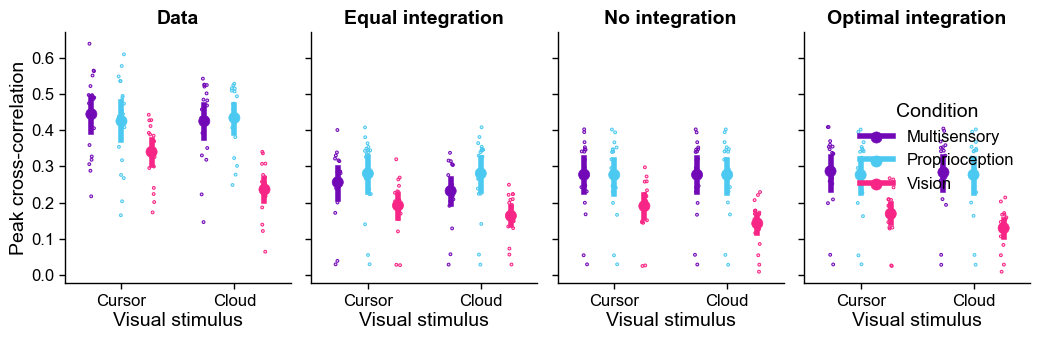

In [17]:
g = (so.Plot(ccg_params, x="Visual target", y="peak", color="Condition")
    .add(so.Dot(pointsize=8), so.Agg(), so.Dodge())
    .add(so.Dots(pointsize=2), so.Dodge(), so.Jitter())
    .add(so.Range(linewidth=4), so.Est(errorbar="ci"), so.Dodge())
    .facet(col="model")
    .scale(x=so.Nominal(order=["Cursor", "Cloud"]), color=so.Nominal(palette))
    .label(x="Visual stimulus", y="Peak cross-correlation")
    .layout(size=(10.5, 3.5))
    # .share(y=False)
)

g.show()

## Compare data and simulations in calibration phase


First, we load the model simulations for all participants

In [19]:
df_sim = pd.concat([pd.read_csv(f"../results/calibration/multisensory-simulations-calibration-{p}_1_2_7453_1000_2500_4_MultisensoryDelayModelPointMassDynamics.csv") for p in participants]).reset_index(drop=True)

df_sim["tracking_error"] = df_sim["lefty_pos"] - (df_sim["righty_pos"])

df_sim["offset_sign"] = df_sim.groupby("participant")["cursor_offset"].transform(
    lambda x: np.sign(x.mean())
)

df_sim["tracking_error"] *= df_sim["offset_sign"]


In [20]:
df = df[df["time_within_trial"] > 3.0]

# replace 'value' with your measurement column name
pre_means = (
    df[df['phase'] == 'pre_cal']
    .groupby(['participant', 'type', 'vis_noise'])['tracking_error']
    .mean()
    .reset_index(name='pre_mean')
)

df = df.merge(pre_means, on=['participant', 'type', 'vis_noise'], how='left')
df['tracking_error'] = df['tracking_error'] - df['pre_mean']
# optional: handle groups with no pre_cal by filling
# df['tracking_error_centered'] = df['value'] - df['pre_mean'].fillna(0)

# add data to simulation dataframe
df["model"] = "data"

In [21]:
df_sim = pd.concat([df, df_sim]).reset_index(drop=True)

In [22]:
df_sim["abs_cursor_offset"] = df_sim["cursor_offset"].abs()

df_sim["model"] = df_sim["model"].map({"data": "Data", "optimal": "Optimal integration", "no_integration": "No integration", "equal_integration": "Equal integration"})
df_sim["Visual target"] = df_sim["vis_noise"].map({1: "Cursor", 2: "Cloud"})
df_sim["Visual uncertainty"] = df_sim["vis_noise"].map({1: "Low", 2: "High"})

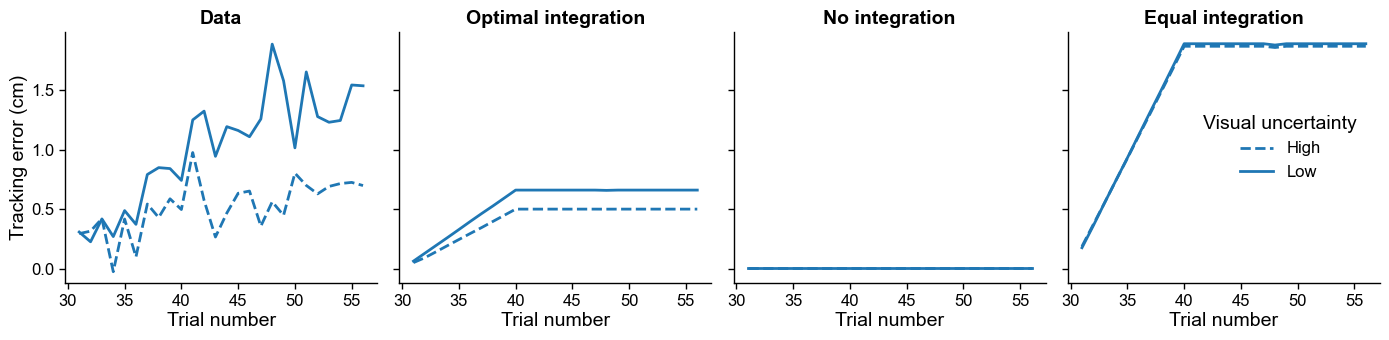

In [25]:
#  "Optimal integration", "No integration"

mean_df = (
    df_sim[
        (df_sim["phase"].isin(["calibration"]))
    ]
    .groupby(["trial_number", "model", "Visual uncertainty", "participant"])[
        ["tracking_error", "abs_cursor_offset"]
    ]
    .median()
    .reset_index()
)


g = (
    so.Plot(
        # df_sim[
        #     (df_sim["phase"].isin(["calibration"]))
        #     & (df_sim["model"].isin(["Data", "Optimal integration", "No integration"]))
        #     # & (df_sim["participant"] == 182095555)
        # ],
        mean_df,
        x="trial_number",
        y="tracking_error",
        linestyle="Visual uncertainty",
    )
    .add(so.Line(), so.Agg("mean"))
    # .add(so.Line(color="gray"), so.Agg(), y="abs_cursor_offset", color=None)
    # .add(so.Band(), so.Est(errorbar="ci"))
    # .add(so.Line(alpha=0.1), so.Agg(), group="participant")
    .scale(linestyle=so.Nominal({"Low": "-", "High": "--"}))
    .facet(col="model", order=["Data", "Optimal integration", "No integration", "Equal integration"])
    .layout(size=(14, 3.5))
    .label(x="Trial number", y="Tracking error (cm)")
)
g.show()